# Sales Forecasting

# Importing Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Loading The Data 

In [11]:
df = pd.read_csv(r'E:\Users\Nirvan\Desktop\Projects\ml_ai\sales_data.csv')

In [67]:
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Product_ID            1000 non-null   int64         
 1   Sale_Date             1000 non-null   datetime64[ns]
 2   Sales_Rep             1000 non-null   object        
 3   Region                1000 non-null   object        
 4   Sales_Amount          1000 non-null   float64       
 5   Quantity_Sold         1000 non-null   int64         
 6   Product_Category      1000 non-null   object        
 7   Unit_Cost             1000 non-null   float64       
 8   Unit_Price            1000 non-null   float64       
 9   Customer_Type         1000 non-null   object        
 10  Discount              1000 non-null   float64       
 11  Payment_Method        1000 non-null   object        
 12  Sales_Channel         1000 non-null   object        
 13  Region_and_Sales_Re

In [68]:
df.shape

(1000, 20)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Product_ID            1000 non-null   int64         
 1   Sale_Date             1000 non-null   datetime64[ns]
 2   Sales_Rep             1000 non-null   object        
 3   Region                1000 non-null   object        
 4   Sales_Amount          1000 non-null   float64       
 5   Quantity_Sold         1000 non-null   int64         
 6   Product_Category      1000 non-null   object        
 7   Unit_Cost             1000 non-null   float64       
 8   Unit_Price            1000 non-null   float64       
 9   Customer_Type         1000 non-null   object        
 10  Discount              1000 non-null   float64       
 11  Payment_Method        1000 non-null   object        
 12  Sales_Channel         1000 non-null   object        
 13  Region_and_Sales_Re

# Creating columns

In [25]:
#Creating the total sales column
df['Total_Sales'] = df['Quantity_Sold'] * df['Unit_Price']

In [41]:
#converting sale_date to datetime format
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

#creating date columns
#month 
df['Month'] = df['Sale_Date'].dt.month
# month and year
df['Month_Year'] = df['Sale_Date'].dt.strftime('%b %y')
#day
df['Day'] = df['Sale_Date'].dt.day
#dayname
df['Day_Name'] = df['Sale_Date'].dt.strftime('%a')
#year
df['Year'] = df['Sale_Date'].dt.year

df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Total_Sales,Month,Month_Year,Day,Day_Name,Year
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,4809.96,2,Feb 23,3,Fri,2023
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,71560.48,4,Apr 23,21,Fri,2023
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David,11142.00,9,Sep 23,21,Thu,2023
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob,174242.25,8,Aug 23,24,Thu,2023
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,9005.23,3,Mar 23,24,Fri,2023


In [45]:
monthly_sales = df.pivot_table(index = ['Month', 'Year'], values='Total_Sales', aggfunc='sum')
monthly_sales = monthly_sales.reset_index()
print(monthly_sales)

    Month  Year  Total_Sales
0       1  2023   7427821.05
1       1  2024     60279.46
2       2  2023   5627477.45
3       3  2023   6008259.41
4       4  2023   5468497.62
5       5  2023   5800626.51
6       6  2023   6142561.23
7       7  2023   4751432.42
8       8  2023   6716190.61
9       9  2023   4557015.58
10     10  2023   6560606.39
11     11  2023   4958930.19
12     12  2023   6250242.79


# Creating the Model

In [46]:
train_data, test_data = train_test_split(monthly_sales, test_size = 0.2, shuffle = False)
print(train_data)
print(test_data)

   Month  Year  Total_Sales
0      1  2023   7427821.05
1      1  2024     60279.46
2      2  2023   5627477.45
3      3  2023   6008259.41
4      4  2023   5468497.62
5      5  2023   5800626.51
6      6  2023   6142561.23
7      7  2023   4751432.42
8      8  2023   6716190.61
9      9  2023   4557015.58
    Month  Year  Total_Sales
10     10  2023   6560606.39
11     11  2023   4958930.19
12     12  2023   6250242.79


In [50]:
#training the model
X_train = train_data[['Month', 'Year']]
y_train = train_data['Total_Sales']

In [51]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [52]:
train_score = model.score(X_train, y_train)
print(train_score)

0.8698907871320469


In [53]:
#model predictions
X_test = test_data[['Month', 'Year']]
y_test = test_data['Total_Sales']

In [58]:
y_pred = model.predict(X_test)
print(X_test)
print(y_pred)
print(y_test)

    Month  Year
10     10  2023
11     11  2023
12     12  2023
[4995264.14472198 4827652.93188858 4660041.71905518]
10    6560606.39
11    4958930.19
12    6250242.79
Name: Total_Sales, dtype: float64


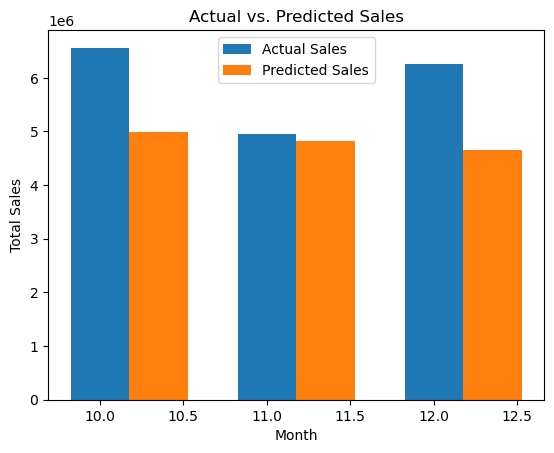

In [65]:
bar_width = 0.35

x= X_test['Month']

plt.bar(x, y_test, label='Actual Sales', width = bar_width)
plt.bar(x + bar_width, y_pred, label = 'Predicted Sales', width = bar_width)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Actual vs. Predicted Sales')
plt.legend()
plt.show()